<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Here we load and clean the historical data of loan transactions. This data was sourced from Kaggle therefore it is anonymised. 
</div>

<div style="
    font-size: 14px;
    font-weight: bold;
    font-color: #e0e0e0;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Dataset:
</div> <div style="
    font-size: 14px;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    LendingClub Loan Data (CSV) https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?select=loan.csv
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
use_cols = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "grade",
    "open_acc",
    "revol_util",
    "earliest_cr_line"
]
    
    

data = pd.read_csv(r"C:\Users\thany\Downloads\loan.csv\loan.csv", usecols=use_cols)

<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    A quick inspection of the data before we proceed.
</div>

In [3]:
data.head()

,loan_amnt,term,int_rate,installment,grade,annual_inc,loan_status,dti,earliest_cr_line,open_acc,revol_util
0,2500,36 months,13.56,84.92,C,55000.0,Current,18.24,Apr-2001,9.0,10.3
1,30000,60 months,18.94,777.23,D,90000.0,Current,26.52,Jun-1987,13.0,24.2
2,5000,36 months,17.97,180.69,D,59280.0,Current,10.51,Apr-2011,8.0,19.1
3,4000,36 months,18.94,146.51,D,92000.0,Current,16.74,Feb-2006,10.0,78.1
4,30000,60 months,16.14,731.78,C,57250.0,Current,26.35,Dec-2000,12.0,3.6


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   loan_amnt         int64  
 1   term              object 
 2   int_rate          float64
 3   installment       float64
 4   grade             object 
 5   annual_inc        float64
 6   loan_status       object 
 7   dti               float64
 8   earliest_cr_line  object 
 9   open_acc          float64
 10  revol_util        float64
dtypes: float64(6), int64(1), object(4)
memory usage: 189.7+ MB


In [5]:
print(data["loan_status"].value_counts())

print("Here we see the statuses of the loans of the clients.")

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64
Here we see the statuses of the loans of the clients.


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    The original dataset was very large and contained a lot of information that we do not need for this model so we have trimmed it down for better loading speed and cleaner reading. It initially had 145 columns, we have selected eleven of the ones we need. 5 of the 11 columns contains float entries, that is decimal point numbers. 2 of the columns have integer values and 4 of them are objects. We have also trimmed the dataset to just the first 1,000,000 entries to train and test our model with.
</div>

In [6]:
# We will create a new column Crediy History Years from the object column earliest_cr_line.

data["earliest_cr_line"] = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y", errors="coerce")

data["credit_history_years"] = (pd.Timestamp("today") - data["earliest_cr_line"]).dt.days/365

data["credit_history_years"] = data["credit_history_years"].round(1)

In [7]:
# We first create a column of defaulted and paid off loans from clients
data = data[data["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
data.loc[:, "default"] = data["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})


In [8]:
data[["credit_history_years", "default"]].head()
data["credit_history_years"].describe()

count    1.303607e+06
mean     2.708204e+01
std      7.597769e+00
min      1.050000e+01
25%      2.180000e+01
50%      2.570000e+01
75%      3.100000e+01
max      9.200000e+01
Name: credit_history_years, dtype: float64

In [9]:
# The cell below produced a ValueError at first so we are making a minor change to fix that

data["term"] = (
    data["term"].astype(str).str.extract(r"(\d+)").astype(int))

<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Now we will encode some features and also split the dataset into what we'll use to train and what we'll use to test the model. 
</div>

In [10]:
data = data.sample(n = len(data), random_state=42)

In [11]:
Y = data["default"].values
X = data.loc[:, data.columns != "default"]

In [12]:
X.shape, Y.shape # Confirmation

((1303607, 12), (1303607,))

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.3, # We use a 70/30 split
    random_state=42,
    stratify=Y
)

In [14]:
categorical_features = ["grade"]

numerical_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "open_acc",
    "revol_util",
    "credit_history_years"
]

<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We begin building the Processing Pipeline.
</div>

In [15]:
# While later building the regression model we were met with a NaN value so in this cell we will implement code to handle that error

from sklearn.impute import SimpleImputer

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We'll construct the linear regression model
</div>

In [17]:

from sklearn.linear_model import LogisticRegression

log_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter = 1000))
         ]
)

# Let's train it

log_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Now that we have our pipeline let's evaluate the model.
</div>

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [19]:
Y_pred = log_model.predict(X_test)
Y_proba = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba))

Accuracy: 0.7999708501775837
ROC-AUC: 0.6993489519408884


In [20]:
report = classification_report(Y_test, Y_pred, output_dict = True)
df_report = pd.DataFrame(report).T

def highlight_low(val, threshold=0.6):
    return "background-color: #f8d7da" if val < threshold else ""

def highlight_low1(val, threshold=0.4):
    return "background-color: #f8d7da" if val < threshold else ""

def highlight(val, threshold=30000):
    return "background-color: #f8d7da" if 10 < val < threshold else ""

df_report.style \
    .format("{:.3f}") \
    .map(highlight, subset=["support"]) \
    .map(highlight_low, subset=["precision"]) \
    .map(highlight_low1, subset=["recall", "f1-score"]) \
    .set_caption("Classification Report") \
    .set_table_styles([
        {"selector": "table",
         "props": [("border", "2px solid black")]},
        {"selector": "th, td",
         "props": [("border", "1px solid black")]}
    ])




,precision,recall,f1-score,support
0,0.804,0.992,0.888,312586.000
1,0.527,0.034,0.063,78497.000
accuracy,0.800,0.800,0.800,0.800
macro avg,0.665,0.513,0.476,391083.000
weighted avg,0.748,0.800,0.723,391083.000


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Using our primary metric of choice which Receiver Operating Characteristic - Area Under the Curve. this measures how well the model separates defaulters from non-defaulters. The result from our model - ROC-AUC: ROC-AUC: 0.6993487927123793. Which is roughly 0.7. This means are model does a decent job of separating defaulters from non-defaulters. For referenc a score of 0.5 would mean our model is randomly guessing, a score of 0.8+ means the model is very good. Our model does an okay job landing in between 0.5 and 0.8 but closer to 0.8.
</div>

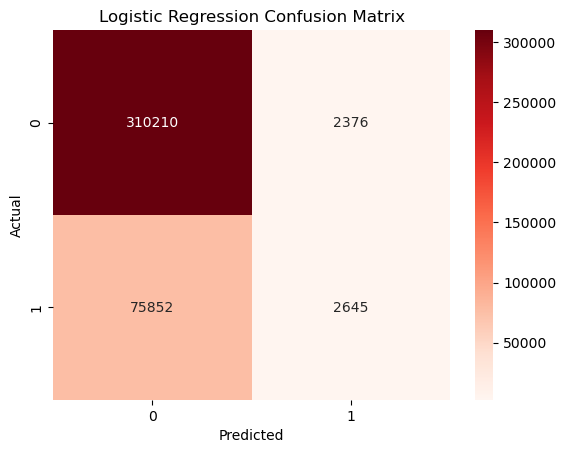

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We will implement a tree based model to improve performance and extract interpretable drivers of default(feature importance). This will be achieved using a Random Forest pipeline.
</div>

In [22]:
from sklearn.ensemble import RandomForestClassifier

We will reuse the same preprocessor

In [23]:
rf_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators = 300,
            max_depth = 12,
            min_samples_leaf = 50,
            random_state = 42,
            n_jobs = -1
        ))
    ]
)

In [24]:
# Training the model

rf_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
Y_pred_rf = rf_model.predict(X_test)
Y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba_rf))

Accuracy: 0.8008785858756325
ROC-AUC: 0.7065046480104761


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    The ROC-AUC is slightly higher using the Tree-based model at 0.7064889368393306 (Logistic Regression ROC-AUC: 0.6993487927123793). This means this model is a bit better than the previous one with a higher accuracy score as well.
</div>

<div style="
    font-size: 14px;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We used preprocessing so we must extract feature names. Extracting feature importance is critcial in our case.
</div>

In [26]:
feature_names_num = numerical_features
feature_names_cat = rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

In [27]:
# Extracting importances

importances = rf_model.named_steps["classifier"].feature_importances_

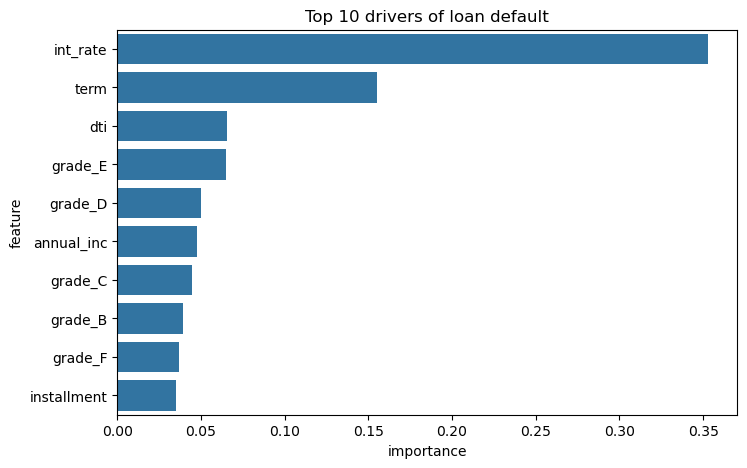

In [28]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending = False)

plt.figure(figsize = (8, 5))
sns.barplot(
    data = importance_df.head(10),
    x = "importance",
    y = "feature"
)
plt.title("Top 10 drivers of loan default")
plt.show()

Above we have tje top 10 drivers of loan default following our feature extraction. We observe te following:

- Interest rate is the most important driver of loan defaults by a large margin. It has an importance score of around 35%.
- Interest rate and the credit grade combined emerge as strong predictors of default risk.
- LendingClub's pricing framework is risk-based so this comes as no surprise.
- Debt to income(dti) and term length also contribute greatly.

In [29]:
import joblib
joblib.dump(rf_model, "credit_default_pred_rf.pkl")


['credit_default_pred_rf.pkl']

In [30]:
joblib.dump(log_model, "credit_default_pred_log.pkl")

['credit_default_pred_log.pkl']